In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

# Setup paths relative to notebook location
CSV_PATH = os.path.normpath(os.path.join(os.getcwd(), '..', 'data', 'raw', 'group17_sti_survey_raw.csv'))
df = pd.read_csv(CSV_PATH)

# Clean columns to standard snake_case
df.columns = (
    df.columns.str.lower()
    .str.strip()
    .str.replace(r'[\s/]+', '_', regex=True)
    .str.replace(r'[()*.]', '', regex=True)
)

print(f"Dataset securely loaded: {len(df)} rows × {len(df.columns)} columns")

Matplotlib is building the font cache; this may take a moment.


Dataset securely loaded: 333 rows × 87 columns


<Figure size 1000x400 with 0 Axes>

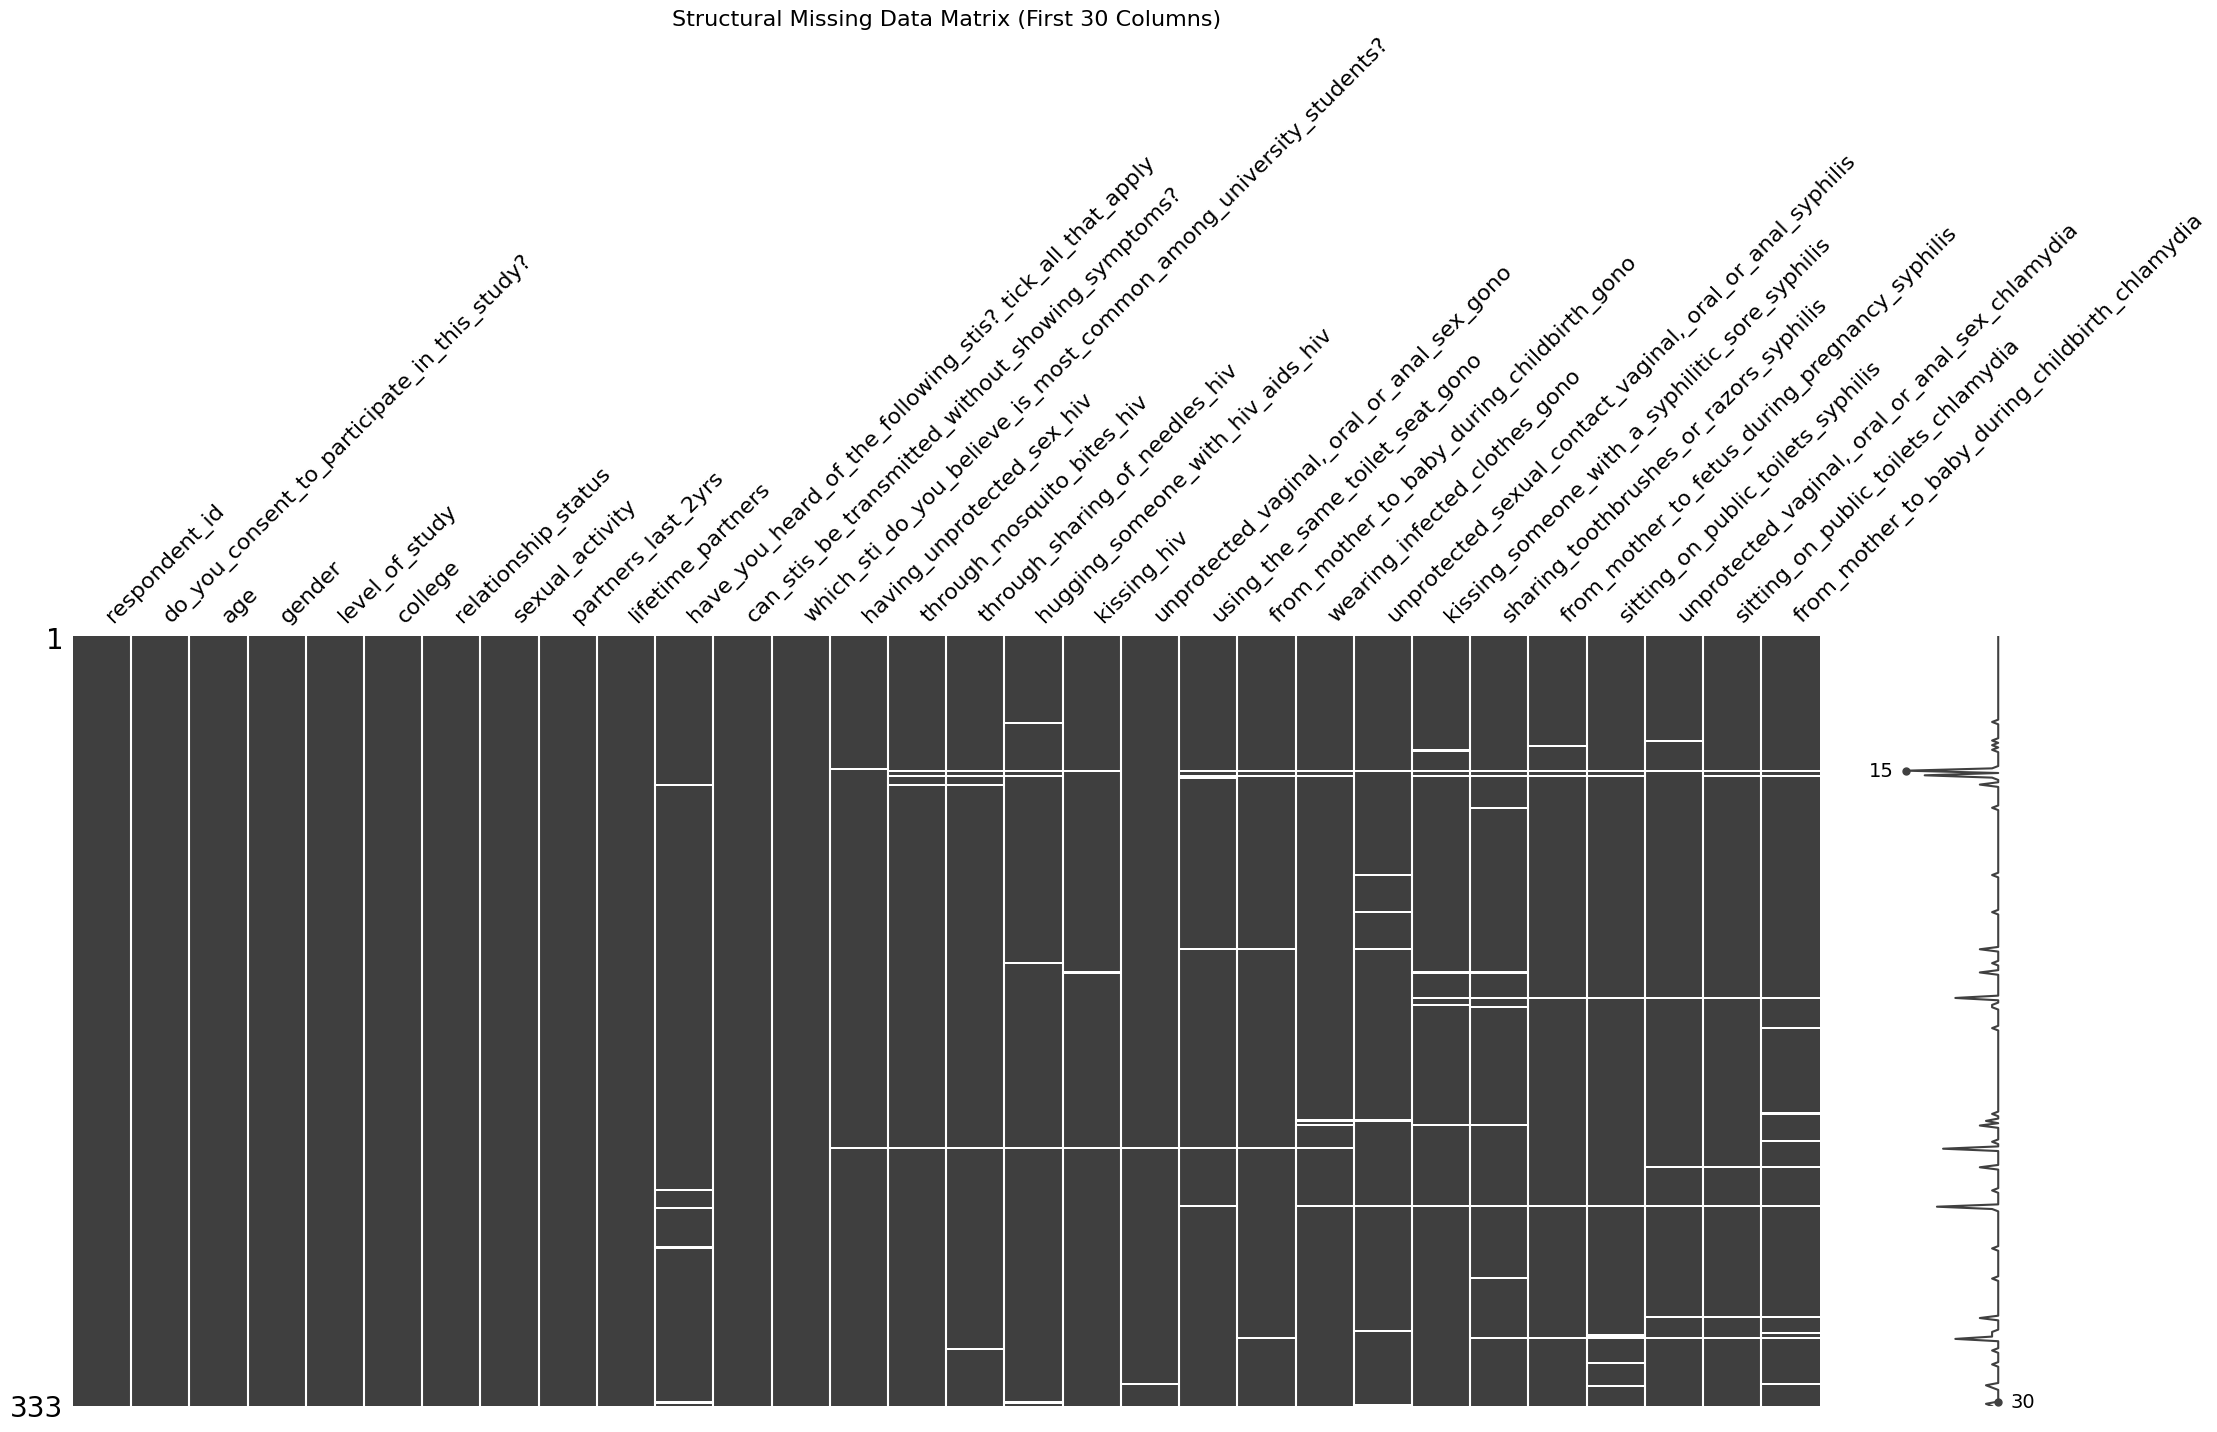

In [2]:
# Visually plot where missing values exist across your 87 columns
plt.figure(figsize=(10, 4))
msno.matrix(df.iloc[:, :30]) # Displays missing data layout for the first 30 columns
plt.title("Structural Missing Data Matrix (First 30 Columns)", fontsize=16)
plt.show()

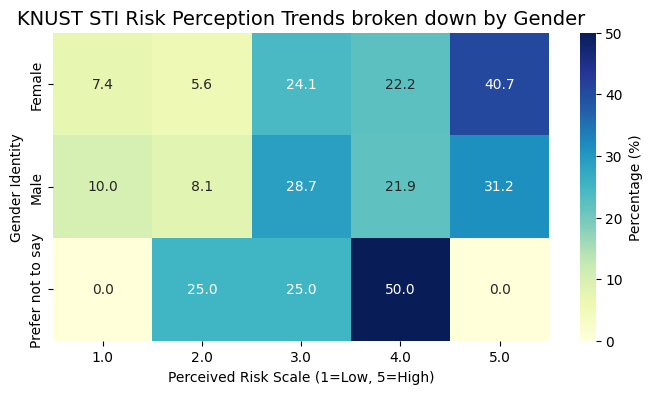

In [3]:
# Cross-tabulate Gender identity against the Raw Risk Perception Likert scale
cross_tab = pd.crosstab(
    df['gender'], 
    df['how_likely_is_it_that_students_at_knust_are_at_risk_of_contracting_stis?'], 
    normalize='index'
) * 100

# Plot as a beautifully formatted heatmap matrix
plt.figure(figsize=(8, 4))
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='.1f', cbar_kws={'label': 'Percentage (%)'})
plt.title("KNUST STI Risk Perception Trends broken down by Gender", fontsize=14)
plt.ylabel("Gender Identity")
plt.xlabel("Perceived Risk Scale (1=Low, 5=High)")
plt.show()

======= FEATURES WITH NULL RESPONSES =======
                                                    Missing Counts  \
in_your_opinion,_what_is_the_most_effective_way...              95   
from_mother_to_baby_during_childbirth_chlamydia                 12   
sharing_food_or_drinks_chlamydia                                11   
sharing_toothbrushes_or_razors_syphilis                         10   
what_is_a_common_symptom_of_chlamydia?                           9   
touching_infected_clothing_chlamydia                             9   
what_is_a_common_symptom_of_syphilis?                            9   
can_untreated_chlamydia_cause_infertility_in_wo...               9   
what_is_a_common_symptom_of_gonorrhea?                           8   
unprotected_sexual_contact_vaginal,_oral_or_ana...               8   
kissing_someone_with_a_syphilitic_sore_syphilis                  8   
sitting_on_public_toilets_syphilis                               8   
do_you_consistently_use_condoms_during_sexual

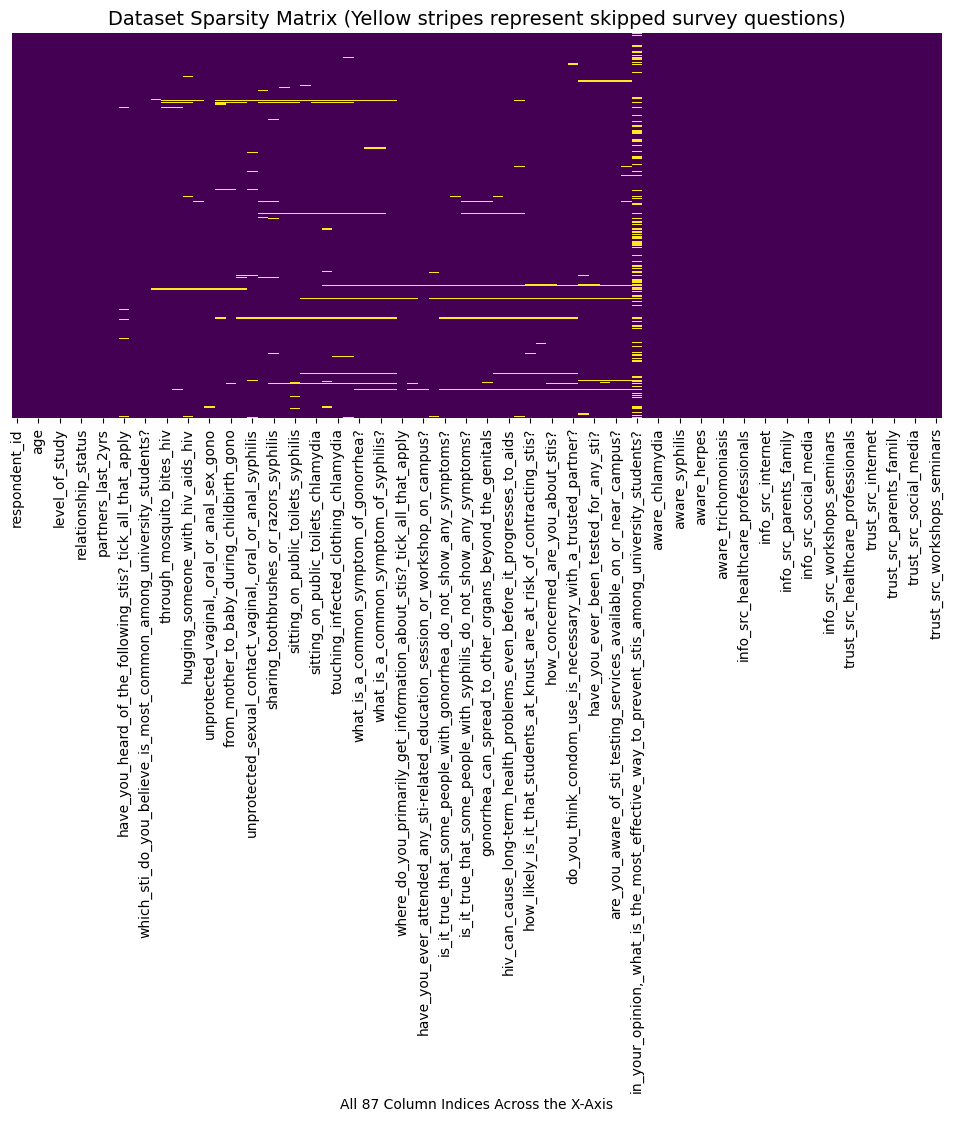

In [4]:
# 1. Isolate and calculate missing percentages per column
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df)) * 100
null_frame = pd.DataFrame({'Missing Counts': missing_data, 'Percentage (%)': missing_pct})
null_frame = null_frame[null_frame['Missing Counts'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("======= FEATURES WITH NULL RESPONSES =======")
if null_frame.empty:
    print("Perfect dataset structure: Zero missing data points found.")
else:
    print(null_frame)
print("============================================")

# 2. Visualize missing data density matrix using a Seaborn heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Dataset Sparsity Matrix (Yellow stripes represent skipped survey questions)", fontsize=14)
plt.xlabel("All 87 Column Indices Across the X-Axis")
plt.show()

In [5]:
# Automatically discover and profile every categorical column
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print(f"Found {len(categorical_cols)} categorical survey questions out of {len(df.columns)} total features.\n")

# Loop through and profile sample chunks of categorical columns (Change slice [:5] to see more)
for col in categorical_cols[:5]: 
    print(f"📋 Profile for Column: [{col.upper()}]")
    print(f"   Unique categories: {df[col].nunique()}")
    print(f"   Most frequent answer: '{df[col].mode()[0]}' ({df[col].value_counts().iloc[0]} responses)")
    print("   Distribution:")
    freq_df = pd.DataFrame({
        'Count': df[col].value_counts(dropna=False),
        'Percentage (%)': df[col].value_counts(normalize=True, dropna=False) * 100
    })
    print(freq_df)
    print("-" * 50)

Found 56 categorical survey questions out of 87 total features.

📋 Profile for Column: [RESPONDENT_ID]
   Unique categories: 333
   Most frequent answer: 'STI-001' (1 responses)
   Distribution:
               Count  Percentage (%)
respondent_id                       
STI-001            1          0.3003
STI-002            1          0.3003
STI-003            1          0.3003
STI-004            1          0.3003
STI-005            1          0.3003
...              ...             ...
STI-329            1          0.3003
STI-330            1          0.3003
STI-331            1          0.3003
STI-332            1          0.3003
STI-333            1          0.3003

[333 rows x 2 columns]
--------------------------------------------------
📋 Profile for Column: [DO_YOU_CONSENT_TO_PARTICIPATE_IN_THIS_STUDY?]
   Unique categories: 1
   Most frequent answer: 'Yes' (333 responses)
   Distribution:
                                              Count  Percentage (%)
do_you_consent_to_partic

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16844\1224684074.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


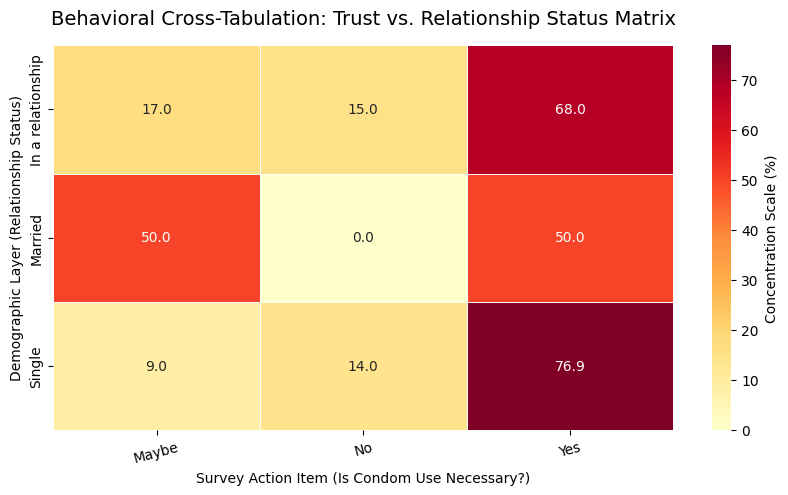

In [6]:
# 1. Cross-tabulate relationship status against condom necessity questions
contingency_matrix = pd.crosstab(
    df['relationship_status'], 
    df['do_you_think_condom_use_is_necessary_with_a_trusted_partner?'],
    normalize='index' # Formats cells as row percentages
) * 100

# 2. Render as an interactive, publication-ready visual heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(
    contingency_matrix, 
    annot=True,          # Overlays actual percentage text inside the grid boxes
    fmt=".1f",           # Limits decimals to 1 place
    cmap="YlOrRd",       # Yellow-Orange-Red gradient highlighting high density zones
    linewidths=0.5,      # Adds subtle grid separation borders
    cbar_kws={'label': 'Concentration Scale (%)'}
)

plt.title("Behavioral Cross-Tabulation: Trust vs. Relationship Status Matrix", fontsize=14, pad=15)
plt.ylabel("Demographic Layer (Relationship Status)")
plt.xlabel("Survey Action Item (Is Condom Use Necessary?)")
plt.xticks(rotation=15)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16844\1221533346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


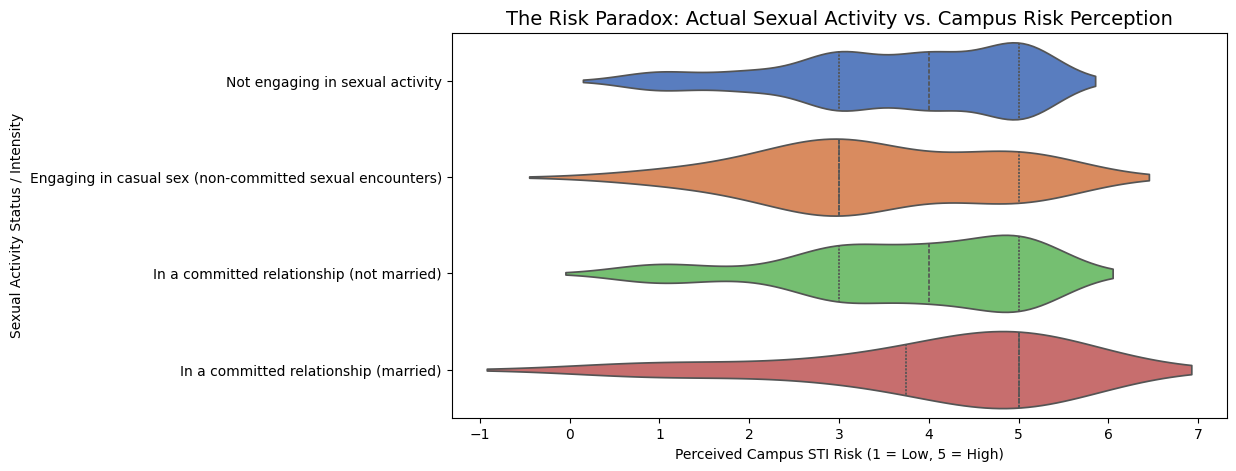

In [7]:
# Copy and run in a new Jupyter cell
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df, 
    x='how_likely_is_it_that_students_at_knust_are_at_risk_of_contracting_stis?', 
    y='sexual_activity', # Replace with your exact partner count column if numerical
    palette='muted',
    inner='quartile'
)
plt.title("The Risk Paradox: Actual Sexual Activity vs. Campus Risk Perception", fontsize=14)
plt.xlabel("Perceived Campus STI Risk (1 = Low, 5 = High)")
plt.ylabel("Sexual Activity Status / Intensity")
plt.show()

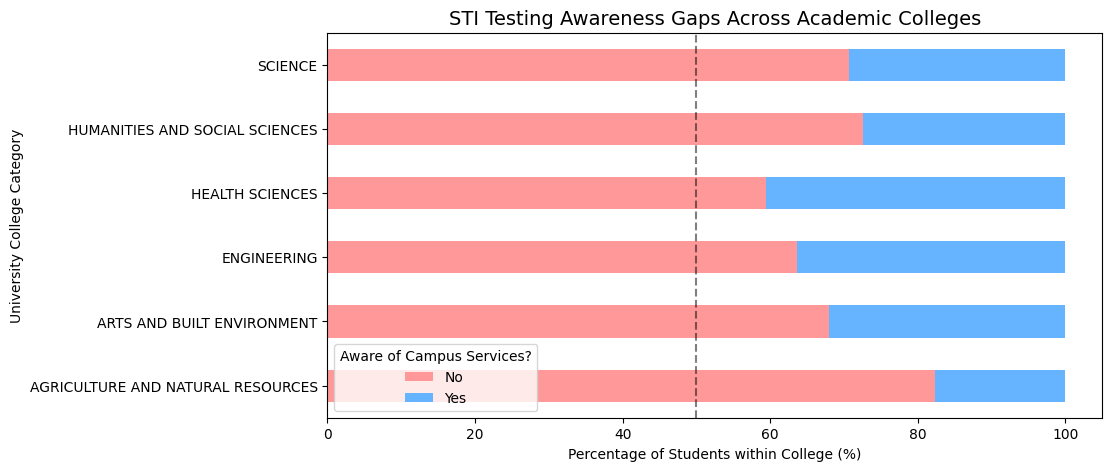

In [8]:
# Copy and run in a new Jupyter cell
college_awareness = pd.crosstab(
    df['college'], 
    df['are_you_aware_of_sti_testing_services_available_on_or_near_campus?'], 
    normalize='index'
) * 100

college_awareness.plot(kind='barh', stacked=True, figsize=(10, 5), color=['#ff9999','#66b3ff'])
plt.title("STI Testing Awareness Gaps Across Academic Colleges", fontsize=14)
plt.xlabel("Percentage of Students within College (%)")
plt.ylabel("University College Category")
plt.legend(title="Aware of Campus Services?", loc='lower left')
plt.axvline(x=50, color='black', linestyle='--', alpha=0.5) # Center benchmark line
plt.show()

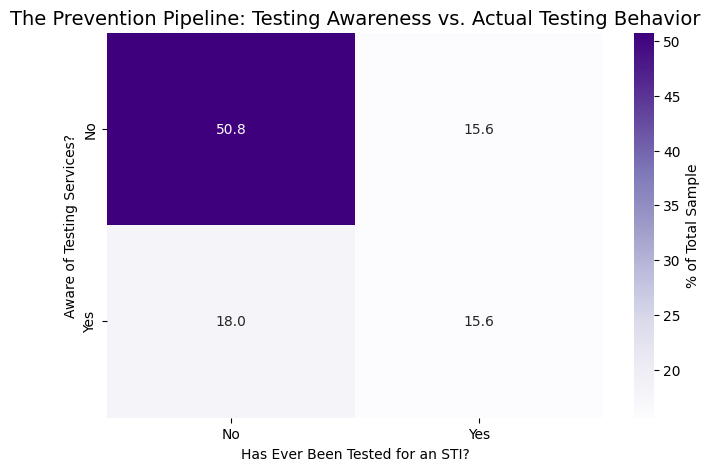

In [9]:
# Copy and run in a new Jupyter cell
pipeline_matrix = pd.crosstab(
    df['are_you_aware_of_sti_testing_services_available_on_or_near_campus?'],
    df['have_you_ever_been_tested_for_any_sti?'],
    normalize='all' # Normalized across the ENTIRE student body base
) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(pipeline_matrix, annot=True, fmt=".1f", cmap="Purples", cbar_kws={'label': '% of Total Sample'})
plt.title("The Prevention Pipeline: Testing Awareness vs. Actual Testing Behavior", fontsize=14)
plt.ylabel("Aware of Testing Services?")
plt.xlabel("Has Ever Been Tested for an STI?")
plt.show()


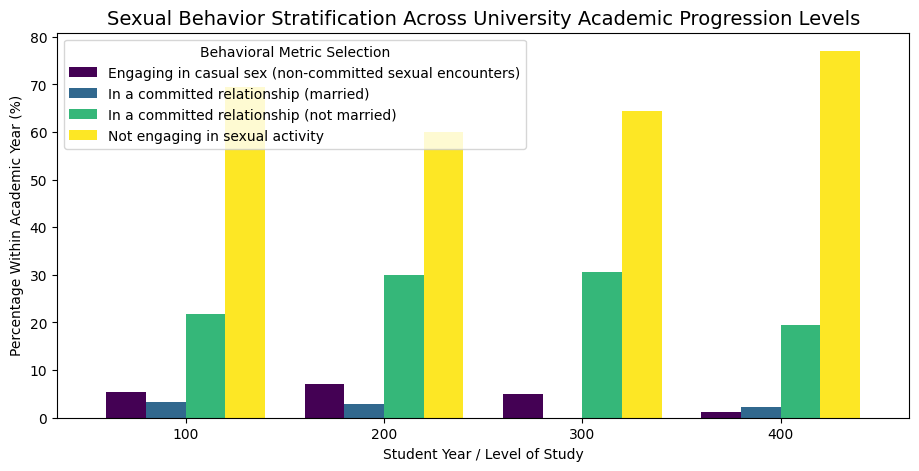

In [10]:
# Copy and run in a new Jupyter cell
progression = pd.crosstab(df['level_of_study'], df['sexual_activity'], normalize='index') * 100

# Reorder indices so they don't sort alphabetically
level_order = ['100', '200', '300', '400', 'postgraduate']
progression = progression.reindex([l for l in level_order if l in progression.index])

progression.plot(kind='bar', figsize=(11, 5), width=0.8, cmap='viridis')
plt.title("Sexual Behavior Stratification Across University Academic Progression Levels", fontsize=14)
plt.ylabel("Percentage Within Academic Year (%)")
plt.xlabel("Student Year / Level of Study")
plt.xticks(rotation=0)
plt.legend(title="Behavioral Metric Selection")
plt.show()

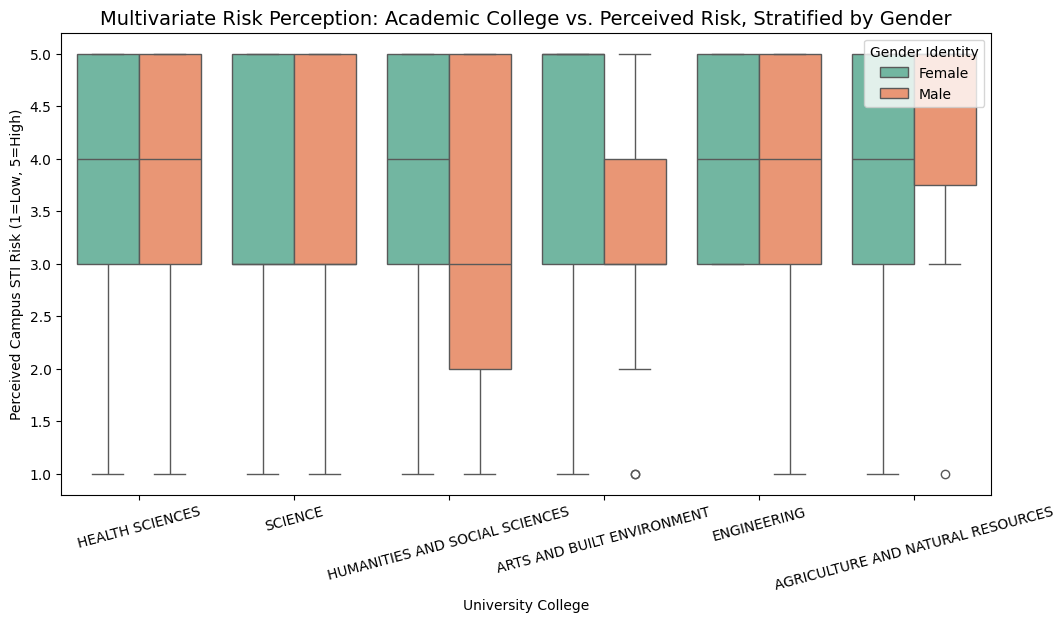

In [11]:
# Copy and run in a new Jupyter cell
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df[df['gender'].isin(['Female', 'Male'])], # Filter out small n-counts for clean plotting
    x='college', 
    y='how_likely_is_it_that_students_at_knust_are_at_risk_of_contracting_stis?', 
    hue='gender', 
    palette='Set2'
)
plt.title("Multivariate Risk Perception: Academic College vs. Perceived Risk, Stratified by Gender", fontsize=14)
plt.xlabel("University College")
plt.ylabel("Perceived Campus STI Risk (1=Low, 5=High)")
plt.legend(title="Gender Identity", loc='upper right')
plt.xticks(rotation=15)
plt.show()

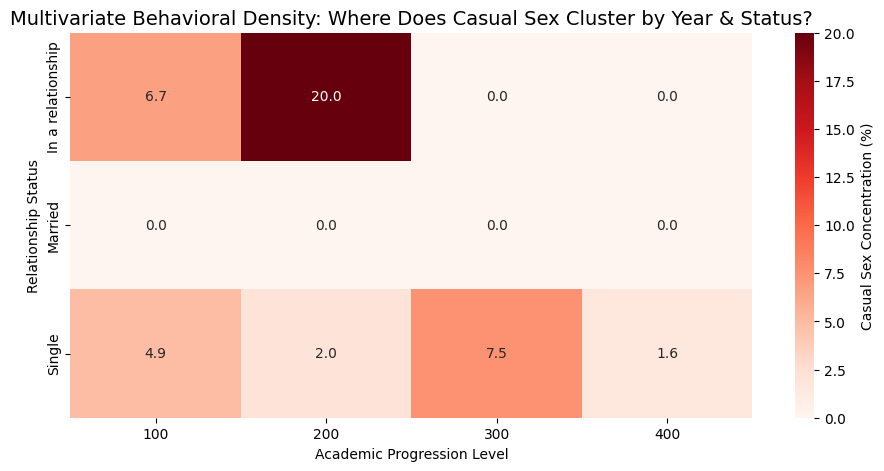

In [12]:
# 1. Group the dataset by three variables simultaneously
multi_pivot = df.groupby(['relationship_status', 'level_of_study'])['sexual_activity'].apply(
    lambda x: (x == 'Engaging in casual sex (non-committed sexual encounters)').sum() / len(x) * 100
).unstack().fillna(0)

# Reorder columns to mirror university progression cleanly
level_order = ['100', '200', '300', '400', 'postgraduate']
multi_pivot = multi_pivot.reindex(columns=[l for l in level_order if l in multi_pivot.columns])

# 2. Plot the multi-variable intersection
plt.figure(figsize=(11, 5))
sns.heatmap(multi_pivot, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Casual Sex Concentration (%)'})
plt.title("Multivariate Behavioral Density: Where Does Casual Sex Cluster by Year & Status?", fontsize=14)
plt.ylabel("Relationship Status")
plt.xlabel("Academic Progression Level")
plt.show()

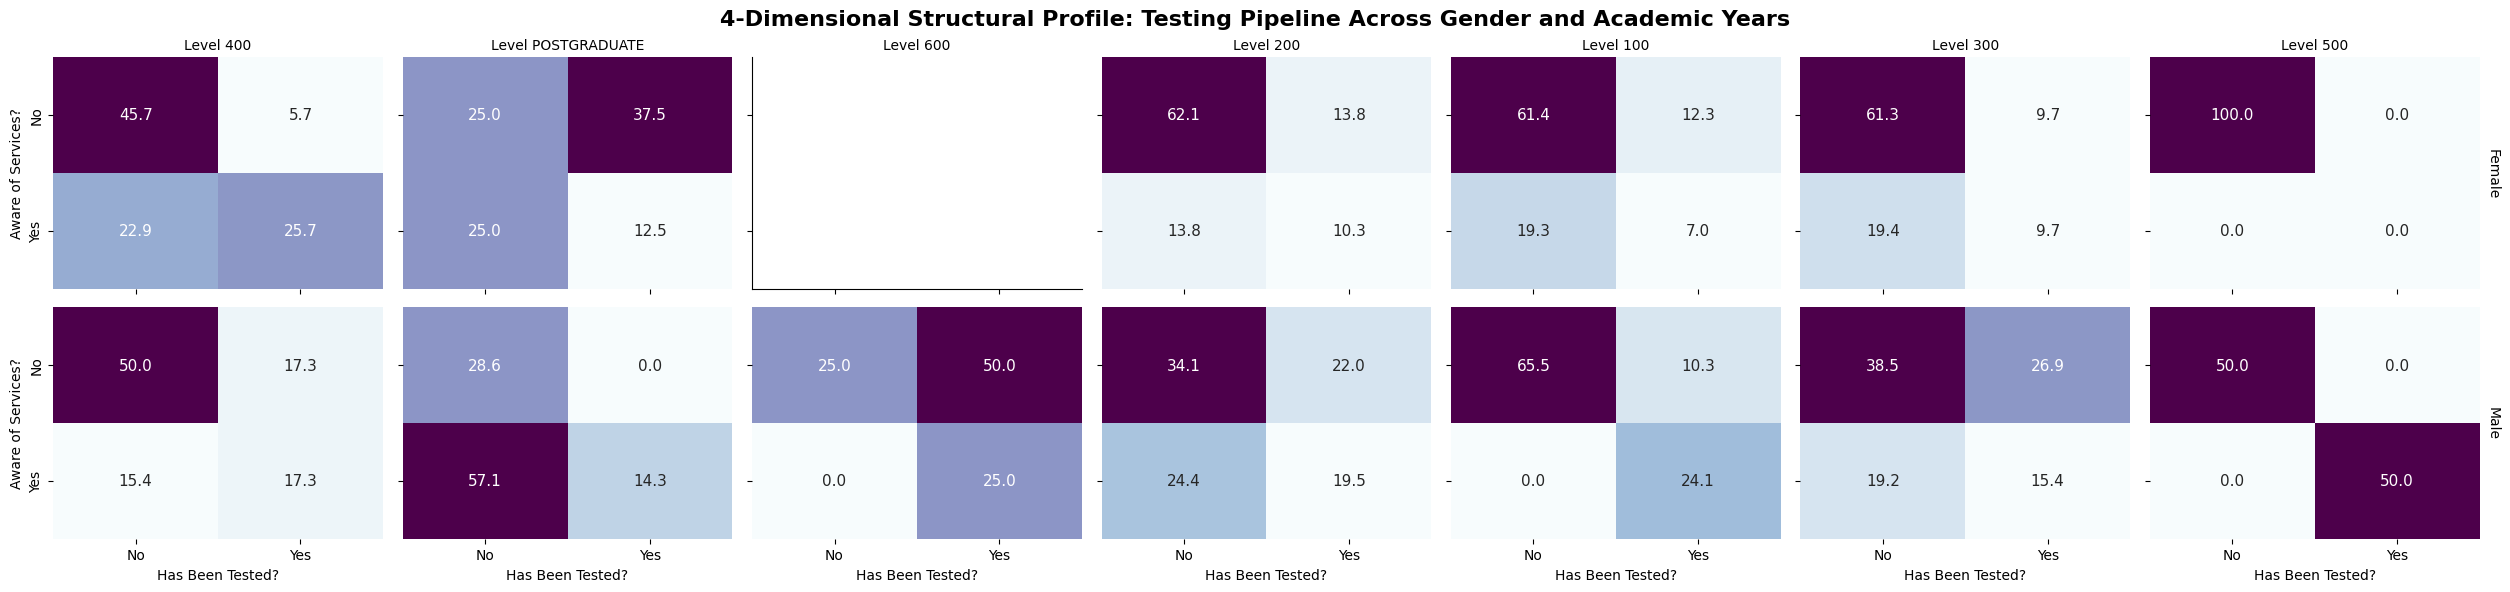

In [13]:
# Custom function to draw individual heatmap quadrants inside a multi-chart grid
def draw_pipeline_heatmap(data, **kwargs):
    if len(data) == 0:
        return
    matrix = pd.crosstab(
        data['are_you_aware_of_sti_testing_services_available_on_or_near_campus?'],
        data['have_you_ever_been_tested_for_any_sti?'],
        normalize='all'
    ) * 100
    
    # Ensure standard 2x2 shape even if responses are missing in a subgroup
    for col in ['No', 'Yes']:
        if col not in matrix.columns: matrix[col] = 0.0
    for idx in ['No', 'Yes']:
        if idx not in matrix.index: matrix.loc[idx] = 0.0
    matrix = matrix.reindex(index=['No', 'Yes'], columns=['No', 'Yes'])
    
    sns.heatmap(matrix, annot=True, fmt=".1f", cmap="BuPu", cbar=False, annot_kws={"size": 11})

# Execute the 4-Variable Facet Grid Matrix
filtered_df = df[df['gender'].isin(['Female', 'Male'])]
g = sns.FacetGrid(filtered_df, col="level_of_study", row="gender", margin_titles=True, height=3, aspect=1.2)
g.map_dataframe(draw_pipeline_heatmap)

g.set_axis_labels("Has Been Tested?", "Aware of Services?")
g.set_titles(col_template="Level {col_name}", row_template="{row_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("4-Dimensional Structural Profile: Testing Pipeline Across Gender and Academic Years", fontsize=16, fontweight='bold')
plt.show()

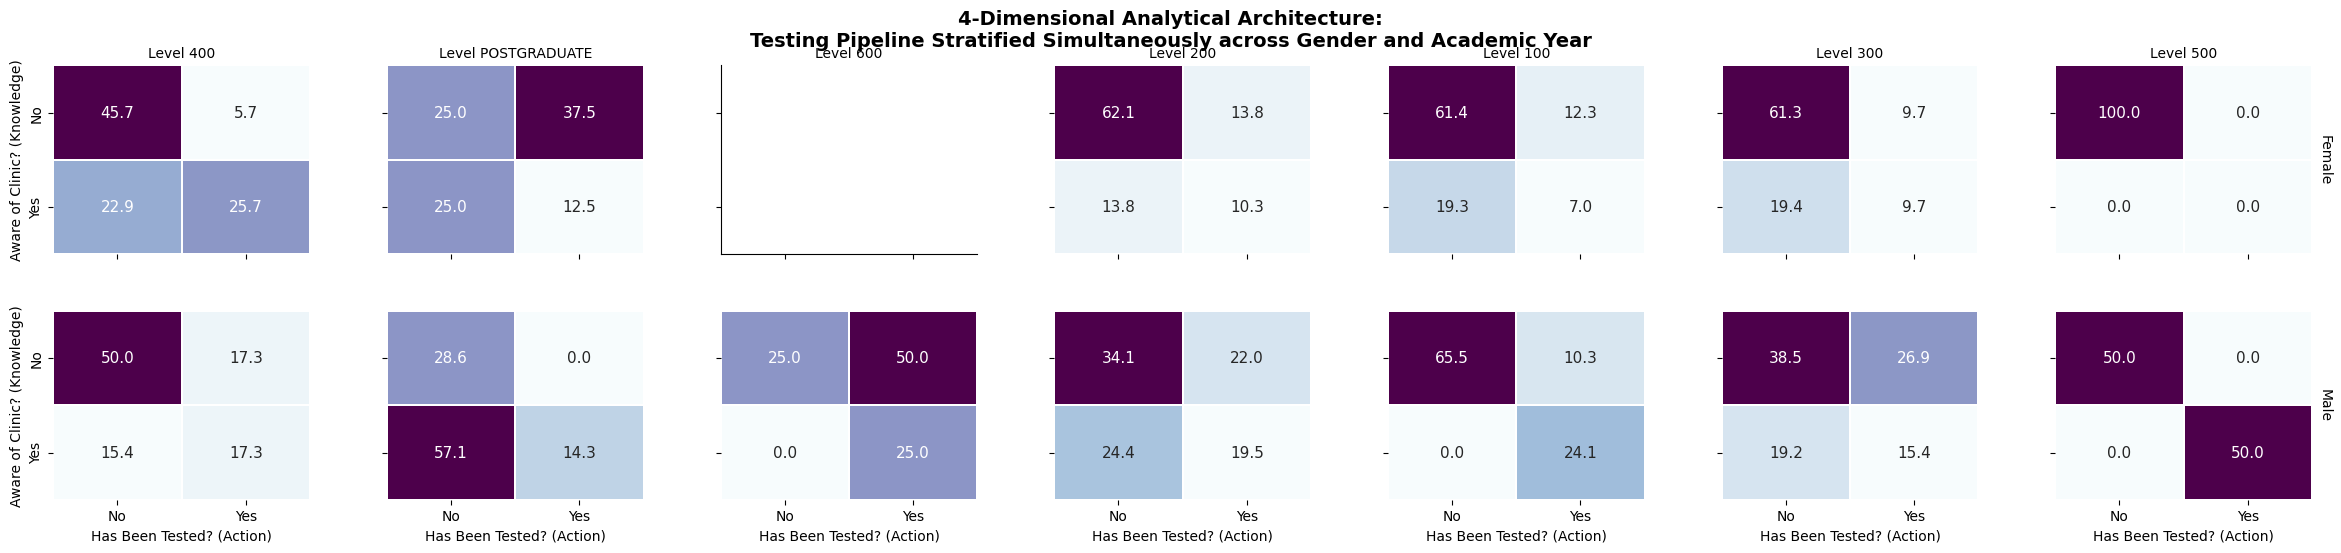

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Custom mapping function to calculate percentages inside each specific grid cell
def draw_pipeline_heatmap(data, **kwargs):
    if len(data) == 0:
        return
    
    # Cross-tabulate base behavioral variables (Normalized across THAT specific subgroup)
    matrix = pd.crosstab(
        data['are_you_aware_of_sti_testing_services_available_on_or_near_campus?'],
        data['have_you_ever_been_tested_for_any_sti?'],
        normalize='all'
    ) * 100
    
    # Guard rail: Guarantee a clean 2x2 matrix shape even if a sub-cohort missed an answer
    for col in ['No', 'Yes']:
        if col not in matrix.columns: matrix[col] = 0.0
    for idx in ['No', 'Yes']:
        if idx not in matrix.index: matrix.loc[idx] = 0.0
    matrix = matrix.reindex(index=['No', 'Yes'], columns=['No', 'Yes'])
    
    # Draw the localized heatmap chunk
    sns.heatmap(
        matrix, 
        annot=True, 
        fmt=".1f", 
        cmap="BuPu", 
        cbar=False, 
        annot_kws={"size": 11},
        linewidths=0.2
    )

# 2. Filter out minor demographic data points for a clean visualization layout
filtered_df = df[df['gender'].isin(['Female', 'Male'])].copy()

# 3. Initialize the FacetGrid structure (Rows = Gender, Columns = Level of Study)
grid = sns.FacetGrid(
    filtered_df, 
    row="gender", 
    col="level_of_study", 
    margin_titles=True, 
    height=2.8, 
    aspect=1.2
)

# 4. Map the execution function across the grid coordinates
grid.map_dataframe(draw_pipeline_heatmap)

# 5. Visual styling updates
grid.set_axis_labels("Has Been Tested? (Action)", "Aware of Clinic? (Knowledge)")
grid.set_titles(col_template="Level {col_name}", row_template="{row_name}")
plt.subplots_adjust(top=0.88, hspace=0.3, wspace=0.3)
grid.fig.suptitle("4-Dimensional Analytical Architecture:\nTesting Pipeline Stratified Simultaneously across Gender and Academic Year", fontsize=14, fontweight='bold')
plt.show()

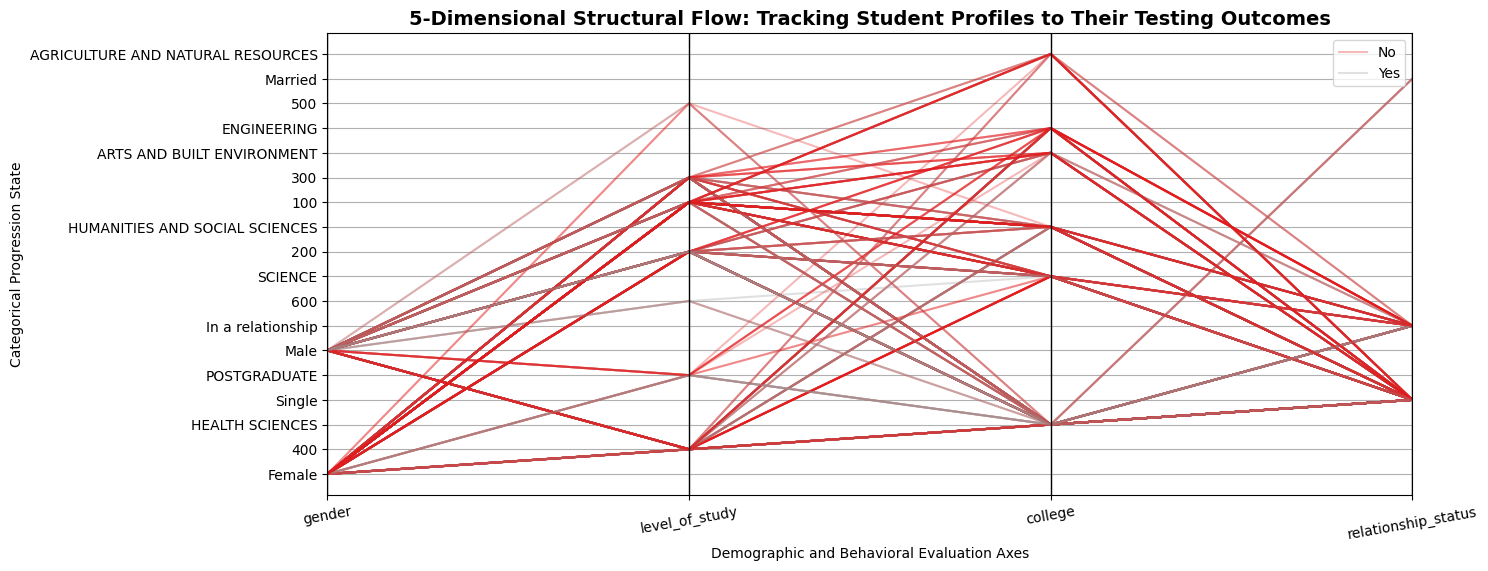

In [15]:
# Copy and run in a new Jupyter cell
from pandas.plotting import parallel_coordinates

# 1. Select a high-dimensional slice of matching columns and clean missing entries
high_dim_df = df[[
    'gender', 'level_of_study', 'college', 
    'relationship_status', 'have_you_ever_been_tested_for_any_sti?'
]].dropna()

# Filter down to primary categories to keep the vertical axes readable
high_dim_df = high_dim_df[high_dim_df['gender'].isin(['Female', 'Male'])]

# 2. Plot the multi-variable data lines, grouping by their final clinical action item
plt.figure(figsize=(14, 6))
parallel_coordinates(high_dim_df, class_column='have_you_ever_been_tested_for_any_sti?', colormap='Set1', alpha=0.3)

plt.title("5-Dimensional Structural Flow: Tracking Student Profiles to Their Testing Outcomes", fontsize=14, fontweight='bold')
plt.xlabel("Demographic and Behavioral Evaluation Axes")
plt.ylabel("Categorical Progression State")
plt.xticks(rotation=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()